 n |    simulated P |  closed-form P
 0 |        3.00000 |        3.00000
 1 |        4.00000 |        4.00000
 2 |        5.33333 |        5.33333
 3 |        7.11111 |        7.11111
 4 |        9.48148 |        9.48148
 5 |       12.64198 |       12.64198
 n |    simulated A |  A(inf) target
 0 |        0.43301 |        0.69282
 1 |        0.57735 |        0.69282
 2 |        0.64150 |        0.69282
 3 |        0.67001 |        0.69282
 4 |        0.68268 |        0.69282
 5 |        0.68831 |        0.69282


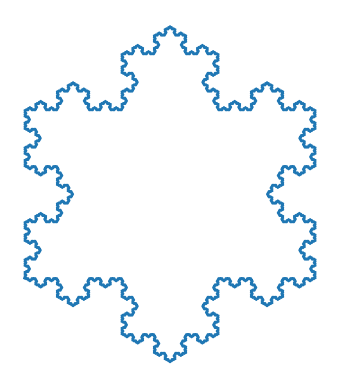

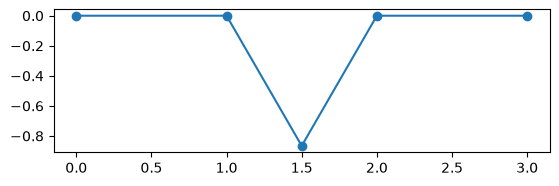

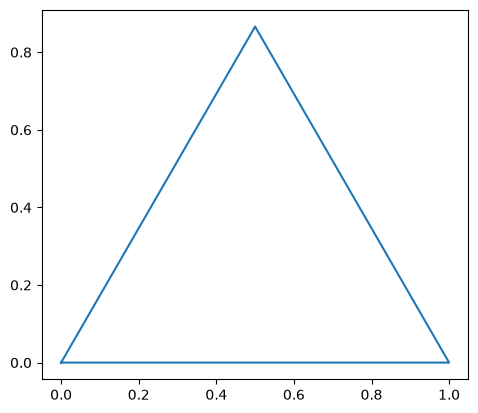

In [35]:
import torch
import matplotlib.pyplot as plt

# Equilateral triangle, centered roughly at origin
p1 = torch.tensor([0.0, 0.0])
p2 = torch.tensor([1.0, 0.0])
p3 = torch.tensor([0.5, 0.5 * (3 ** 0.5)])  # height of equilateral triangle = sqrt(3)/2

# The "polygon" is just a list of points, closed by returning to p1
points = torch.stack([p1, p2, p3, p1])

def rotate(vec, angle_deg):
    theta = torch.deg2rad(torch.tensor(angle_deg))
    cos, sin = torch.cos(theta), torch.sin(theta)
    R = torch.tensor([[cos, -sin],
                       [sin,  cos]])
    return R @ vec  # matrix-vector multiply

def koch_bump(A, B):
    p1 = A + (B - A) / 3
    p3 = A + (B - A) * 2 / 3
    peak = p1 + rotate(p3 - p1, -60)
    return torch.stack([A, p1, peak, p3, B])

##testing that the code above runs on my own, claude gave incorrect code and gave angle 
## of -60 when 60 is needed otherwise looks inverted!
A = torch.tensor([0.0, 0.0])
B = torch.tensor([3.0, 0.0])
bumped = koch_bump(A, B)

def koch_iteration(points):
    new_points = []
    for i in range(len(points) - 1):
        A = points[i]
        B = points[i + 1]
        bumped = koch_bump(A, B)
        # avoid duplicating shared points between consecutive edges
        new_points.append(bumped[:-1]) #why bumped [-1]? because bumped ends in B, and starts B to so otherwise will get duplicated
                                       #points unless slice it off here!
    new_points.append(points[-1:])  # close the shape
    return torch.cat(new_points, dim=0)
        
shape = torch.stack([p1, p2, p3, p1])  # your triangle from step 1

n_iterations = 5
for _ in range(n_iterations):
    shape = koch_iteration(shape)

## Peremiter stuff ( closed form solution)
def perimeter(points):
    diffs = points[1:] - points[:-1]
    lengths = torch.norm(diffs, dim=1)
    return lengths.sum()

shape = torch.stack([p1, p2, p3, p1])
P0 = perimeter(shape)

print(f"{'n':>2} | {'simulated P':>14} | {'closed-form P':>14}")
for n in range(6):
    if n > 0:
        shape = koch_iteration(shape)
    sim_P = perimeter(shape).item()
    formula_P = (P0 * (4/3)**n).item()
    print(f"{n:>2} | {sim_P:>14.5f} | {formula_P:>14.5f}")

### Area stuff
def shoelace_area(points):
    x = points[:, 0]
    y = points[:, 1]
    return 0.5 * torch.abs(torch.sum(x[:-1] * y[1:] - x[1:] * y[:-1]))

shape = torch.stack([p1, p2, p3, p1])  # reset to triangle
A0 = shoelace_area(shape)
A_inf = (8/5) * A0

print(f"{'n':>2} | {'simulated A':>14} | {'A(inf) target':>14}")
for n in range(6):
    if n > 0:
        shape = koch_iteration(shape)
    sim_A = shoelace_area(shape).item()
    print(f"{n:>2} | {sim_A:>14.5f} | {A_inf.item():>14.5f}")

plt.plot(shape[:, 0], shape[:, 1])
plt.gca().set_aspect('equal')
plt.axis('off')
plt.show()

plt.plot(bumped[:, 0], bumped[:, 1], marker='o')
plt.gca().set_aspect('equal')
plt.show()

plt.plot(points[:, 0], points[:, 1])
plt.gca().set_aspect('equal')
plt.show()

In [ ]:
claude referencing : https://claude.ai/share/4dd16005-b536-4a47-9ef2-b6f35aeae735